In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('dataset.csv')
profile = df.iloc[0]

print(profile.head(10))


Sample Name    NTD01
AMEL               X
AMEL.1             Y
CSF1PO            10
CSF1PO.1          10
D10S1248          12
D10S1248.1        16
D12S391           16
D12S391.1         23
D13S317           11
Name: 0, dtype: object


In [2]:
loci_columns = df.columns[2:]

profile_alleles = {}
for locus in loci_columns:
    allele = profile[locus]
    profile_alleles.setdefault(locus, []).append(str(allele))

for locus, alleles in profile_alleles.items():
    print(f"{locus}: Alleles {alleles}")


AMEL.1: Alleles ['Y']
CSF1PO: Alleles ['10']
CSF1PO.1: Alleles ['10']
D10S1248: Alleles ['12']
D10S1248.1: Alleles ['16']
D12S391: Alleles ['16']
D12S391.1: Alleles ['23']
D13S317: Alleles ['11']
D13S317.1: Alleles ['13']
D16S539: Alleles ['11']
D16S539.1: Alleles ['13']
D18S51: Alleles ['16']
D18S51.1: Alleles ['16']
D19S433: Alleles ['13.0']
D19S433.1: Alleles ['16.2']
D1S1656: Alleles ['14']
D1S1656.1: Alleles ['14']
D21S11: Alleles ['29.0']
D21S11.1: Alleles ['29.0']
D22S1045: Alleles ['15']
D22S1045.1: Alleles ['17']
D2S1338: Alleles ['16']
D2S1338.1: Alleles ['16']
D2S441: Alleles ['11.0']
D2S441.1: Alleles ['12']
D3S1358: Alleles ['17']
D3S1358.1: Alleles ['18']
D5S818: Alleles ['11']
D5S818.1: Alleles ['12']
D7S820: Alleles ['8']
D7S820.1: Alleles ['11']
D8S1179: Alleles ['12']
D8S1179.1: Alleles ['16']
FGA: Alleles ['18.2']
FGA.1: Alleles ['23']
Penta D: Alleles ['5.0']
Penta D.1: Alleles ['10.0']
Penta E: Alleles ['11']
Penta E.1: Alleles ['16']
SE33: Alleles ['20.0']
SE33.1:

In [3]:
def calculate_allele_frequencies(data, locus):
    alleles = data[locus].dropna().astype(str).tolist()
    counts = Counter(alleles)
    total = sum(counts.values())
    freqs = {allele: count / total for allele, count in counts.items()}
    return freqs

# Calculate frequencies for an example locus, e.g., 'D10S1248'
locus = 'D10S1248'
allele_freqs = calculate_allele_frequencies(df, locus)

print(f"Allele frequencies at locus {locus}: {allele_freqs}")


Allele frequencies at locus D10S1248: {'12': 0.09090909090909091, '13': 0.45454545454545453, '15': 0.18181818181818182, '9': 0.09090909090909091, '14': 0.18181818181818182}


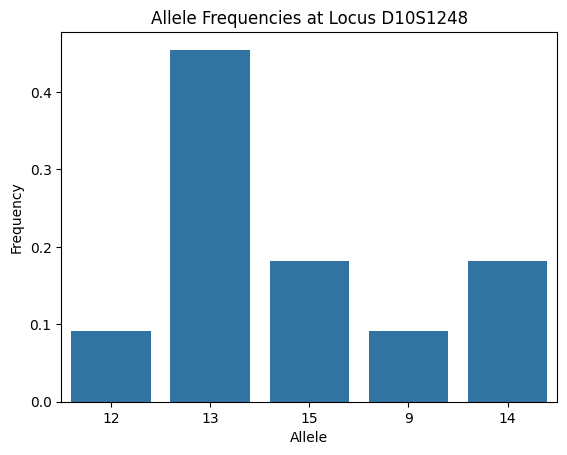

In [4]:
def plot_allele_frequencies(freqs, locus):
    alleles = list(freqs.keys())
    values = list(freqs.values())
    sns.barplot(x=alleles, y=values)
    plt.title(f"Allele Frequencies at Locus {locus}")
    plt.xlabel("Allele")
    plt.ylabel("Frequency")
    plt.show()

# Plot
plot_allele_frequencies(allele_freqs, locus)

In [5]:
def likelihood_ratio(evidence_freqs, suspect_alleles):
    lr = 1.0
    for allele in suspect_alleles:
        ef = evidence_freqs.get(allele, 0.0001)  
        lr *= 1 / ef  
    return lr

sample_alleles = profile_alleles[locus]
lr = likelihood_ratio(allele_freqs, sample_alleles)
print(f"Likelihood ratio for sample alleles at locus {locus}: {lr}")

Likelihood ratio for sample alleles at locus D10S1248: 11.0


In [6]:
# Bayesian posterior calculation
def calculate_posterior(prior_prob, likelihood_ratio):
    posterior = (prior_prob * likelihood_ratio) / (prior_prob * likelihood_ratio + (1 - prior_prob))
    return posterior

# Prior probability (example: 1%)
prior_probability = 0.01

posterior_prob = calculate_posterior(prior_probability, lr)

print(f"Likelihood Ratio for {locus}: {lr:.4f}")
print(f"Posterior Probability: {posterior_prob:.4f}")


Likelihood Ratio for D10S1248: 11.0000
Posterior Probability: 0.1000


In [7]:
loci_of_interest = ['D10S1248', 'D12S391', 'D13S317']  # example loci
def combinelikelihoodratios(likelihood_ratios):
    total_lr = 1.0
    for lr in likelihood_ratios:
        total_lr *= lr
    return total_lr

lrs = []
for locus in loci_of_interest:
    # allele frequencies for the locus
    allele_freqs = calculate_allele_frequencies(df, locus)

    sample_alleles = profile_alleles.get(locus, [])
    # likelihood ratio for this locus
    lr = likelihood_ratio(allele_freqs, sample_alleles)
    lrs.append(lr)
    print(f"Locus: {locus}, LR: {lr:.4f}")

# Combine likelihood ratios
total_lr = combinelikelihoodratios(lrs)

# posterior with prior
prior_probability = 0.01
posterior = calculate_posterior(prior_probability, total_lr)

print(f"Combined LR: {total_lr:.4f}")
print(f"Posterior probability: {posterior:.4f}")


Locus: D10S1248, LR: 11.0000
Locus: D12S391, LR: 11.0000
Locus: D13S317, LR: 1.8333
Combined LR: 221.8333
Posterior probability: 0.6914
